<a href="https://colab.research.google.com/github/asegura4488/EDCO_MachineLearning/blob/main/Semana6/ProblemaClasificacion_RandomizedSearchCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de *churn* bancario con RandomizedSearchCV


> **Versión corregida:** usa Keras 3 directamente y evita la dependencia de SciKeras.

## Objetivo de la clase

Partimos del mismo problema de clasificación binaria del notebook anterior:

- `Exited = 1`: el cliente **abandona** el banco (*churn*).
- `Exited = 0`: el cliente **permanece**.

Ahora queremos responder otra pregunta:

> **¿Cómo elegimos de forma sistemática los hiperparámetros de la red neuronal?**

Usaremos **RandomizedSearchCV** para buscar una buena combinación de arquitectura y parámetros de entrenamiento.

El flujo metodológico será:

1. separar `train / validation / test`;
2. construir un `Pipeline` que contenga **preprocesamiento + red neuronal**;
3. hacer el *tuning* **solo con `train`**, usando validación cruzada estratificada;
4. usar `validation` para seleccionar el umbral de clasificación;
5. usar `test` **una sola vez al final**.

> **Regla central:** `test` no participa ni en el *tuning* de hiperparámetros ni en la selección del *threshold*.

## 1. Instalación e importación de librerías

Esta versión usa **Keras 3** directamente y define un clasificador pequeño compatible con la API de `scikit-learn`.

Esto evita depender de `SciKeras` y deja los hiperparámetros expuestos de forma natural a `GridSearchCV` y `RandomizedSearchCV`.

El notebook detecta automáticamente un backend disponible para Keras (`TensorFlow`, `PyTorch` o `JAX`). En Google Colab normalmente se usará TensorFlow.


In [1]:
# Versión corregida: Keras 3 + scikit-learn, sin SciKeras.
# El backend se selecciona automáticamente: TensorFlow > PyTorch > JAX.

import os
import sys
import subprocess
import importlib.util
from pathlib import Path

# Keras 3 necesita un backend. En Colab normalmente TensorFlow ya está instalado.
if "KERAS_BACKEND" not in os.environ:
    if importlib.util.find_spec("tensorflow") is not None:
        os.environ["KERAS_BACKEND"] = "tensorflow"
    elif importlib.util.find_spec("torch") is not None:
        os.environ["KERAS_BACKEND"] = "torch"
    elif importlib.util.find_spec("jax") is not None:
        os.environ["KERAS_BACKEND"] = "jax"

# Instalamos Keras solo si hace falta.
if importlib.util.find_spec("keras") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "keras>=3.2"])

# Si no hay ningún backend, damos un mensaje claro.
if not any(importlib.util.find_spec(pkg) is not None for pkg in ("tensorflow", "torch", "jax")):
    raise ImportError(
        "Keras necesita un backend. En Colab usa el runtime normal; "
        "en local instala, por ejemplo: pip install tensorflow"
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import keras

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)

SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print("Keras   :", keras.__version__)
print("Backend :", keras.backend.backend())


Keras   : 3.13.2
Backend : tensorflow


## 2. Carga de los datos

Se conserva la misma ruta del notebook anterior. Si estás trabajando localmente, modifica `DATA_PATH` para apuntar al archivo `Churn_Modelling.csv`.

In [2]:
# Carga robusta de Churn_Modelling.csv.
# 1) En Colab intenta montar Drive.
# 2) Busca en varias rutas comunes.
# 3) Si no lo encuentra en Colab, permite subir el CSV manualmente.

try:
    from google.colab import drive, files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

candidate_paths = []

if IN_COLAB:
    try:
        drive.mount("/content/drive", force_remount=False)
    except Exception as exc:
        print("No se pudo montar Drive automáticamente:", exc)

    candidate_paths.extend([
        Path("/content/drive/MyDrive/IntroCienciaDatos/Semana6/Datos/Churn_Modelling.csv"),
        Path("/content/Churn_Modelling.csv"),
    ])

candidate_paths.extend([
    Path("Churn_Modelling.csv"),
    Path("Datos/Churn_Modelling.csv"),
])

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)

if DATA_PATH is None and IN_COLAB:
    print("No encontré Churn_Modelling.csv. Selecciona el archivo desde tu computador.")
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("No se seleccionó ningún archivo CSV.")
    uploaded_name = next(iter(uploaded))
    DATA_PATH = Path(uploaded_name)

if DATA_PATH is None:
    checked = "\n".join(f"  - {p}" for p in candidate_paths)
    raise FileNotFoundError(
        "No se encontró Churn_Modelling.csv.\n"
        "Rutas revisadas:\n"
        f"{checked}\n\n"
        "Copia el archivo a una de esas rutas o cambia candidate_paths."
    )

df = pd.read_csv(DATA_PATH)

required_columns = {
    "Exited", "CreditScore", "Geography", "Gender", "Age",
    "Tenure", "Balance", "NumOfProducts", "HasCrCard",
    "IsActiveMember", "EstimatedSalary"
}
missing = sorted(required_columns.difference(df.columns))
if missing:
    raise ValueError(
        "El CSV no tiene la estructura esperada. "
        f"Faltan estas columnas: {missing}"
    )

print("Archivo :", DATA_PATH)
print("Dimensiones:", df.shape)
display(df.head())


Mounted at /content/drive
Archivo : /content/drive/MyDrive/IntroCienciaDatos/Semana6/Datos/Churn_Modelling.csv
Dimensiones: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Eliminamos identificadores si existen; no fallamos si alguno no está.
cols_to_drop = ["RowNumber", "CustomerId", "Surname"]
df_model = df.drop(
    columns=[c for c in cols_to_drop if c in df.columns]
).copy()

TARGET = "Exited"
y = df_model[TARGET].astype(int)
X = df_model.drop(columns=TARGET)

if not set(y.unique()).issubset({0, 1}):
    raise ValueError("La variable Exited debe ser binaria con valores 0 y 1.")

summary = pd.DataFrame({
    "n": y.value_counts().sort_index(),
    "proporción": y.value_counts(normalize=True).sort_index(),
}).reindex([0, 1], fill_value=0)

summary.index = ["Permanece (0)", "Churn (1)"]
display(summary)


,n,proporción
Permanece (0),7963,0.7963
Churn (1),2037,0.2037


## 3. Separación `train / validation / test`

Mantenemos la misma separación del notebook anterior:

- **60 % train**: aquí ocurre el `GridSearchCV`/`RandomizedSearchCV` y su validación cruzada interna;
- **20 % validation**: se reserva para escoger el *threshold* una vez seleccionado el modelo;
- **20 % test**: evaluación final.

Esto puede parecer que crea “dos validaciones”, pero cumplen funciones diferentes:

- los **folds internos de CV** comparan hiperparámetros;
- `X_val` ayuda después a decidir cómo convertir probabilidades en clases 0/1.

In [4]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25,
    random_state=SEED,
    stratify=y_trainval,
)

print('Train:', X_train.shape, '| churn =', round(y_train.mean(), 3))
print('Val  :', X_val.shape,   '| churn =', round(y_val.mean(), 3))
print('Test :', X_test.shape,  '| churn =', round(y_test.mean(), 3))

Train: (6000, 10) | churn = 0.204
Val  : (2000, 10) | churn = 0.204
Test : (2000, 10) | churn = 0.204


# 4. Punto conceptual clave: el preprocesamiento debe estar DENTRO del Pipeline

En un *tuning* con validación cruzada no debemos hacer esto:

```python
X_train_p = preprocessor.fit_transform(X_train)
grid.fit(X_train_p, y_train)
```

¿Por qué? Porque `preprocessor.fit_transform(X_train)` habría aprendido medias, desviaciones y categorías usando **todo `X_train` antes de crear los folds**.

La forma correcta es:

```text
Pipeline
├── preprocesamiento
│   ├── StandardScaler
│   └── OneHotEncoder
└── KerasClassifier
```

Entonces, para cada fold, `scikit-learn` ejecuta aproximadamente:

```text
fit(preprocesador, fold_train)
transform(fold_train)
transform(fold_validation)
fit(red, fold_train_transformado)
evaluate(red, fold_validation_transformado)
```

Así, el fold de validación **no participa en el ajuste del preprocesador**.

In [5]:
# Identificamos tipos de variables usando únicamente X_train.
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Compatibilidad con versiones recientes y antiguas de scikit-learn.
try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', encoder, categorical_features),
    ],
    remainder='drop',
)

print('Numéricas   :', numeric_features)
print('Categóricas :', categorical_features)

Numéricas   : ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categóricas : ['Geography', 'Gender']


# 5. Convertimos la red Keras en un estimador de scikit-learn

La clase `KerasBinaryClassifier` hereda de `ClassifierMixin` y `BaseEstimator`, por lo que puede vivir dentro de un `Pipeline` y ser clonada por la validación cruzada.

Los hiperparámetros que exploraremos quedan como parámetros normales del estimador:

| Hiperparámetro | Qué controla |
|---|---|
| `units1` | neuronas de la primera capa oculta |
| `units2` | neuronas de la segunda capa |
| `dropout_rate` | regularización por dropout |
| `learning_rate` | tasa de aprendizaje de Adam |
| `batch_size` | tamaño de los lotes de entrenamiento |

La red se reconstruye desde cero en cada `fit`, que es exactamente lo que necesitamos en los distintos folds de validación cruzada.


In [6]:
class KerasBinaryClassifier(ClassifierMixin, BaseEstimator):
    """
    Clasificador binario Keras compatible con la API de scikit-learn.

    La ventaja didáctica es que los hiperparámetros quedan expuestos
    directamente a GridSearchCV/RandomizedSearchCV:
        clf__units1
        clf__units2
        clf__dropout_rate
        clf__learning_rate
        clf__batch_size
    """

    def __init__(
        self,
        units1=32,
        units2=16,
        dropout_rate=0.20,
        learning_rate=1e-3,
        epochs=40,
        batch_size=64,
        verbose=0,
        random_state=42,
    ):
        self.units1 = units1
        self.units2 = units2
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.random_state = random_state

    def _build_model(self, n_features):
        inputs = keras.Input(shape=(n_features,), name="features")

        x = keras.layers.Dense(
            self.units1, activation="relu", name="hidden_1"
        )(inputs)
        x = keras.layers.Dropout(
            self.dropout_rate, name="dropout_1"
        )(x)

        x = keras.layers.Dense(
            self.units2, activation="relu", name="hidden_2"
        )(x)
        x = keras.layers.Dropout(
            self.dropout_rate, name="dropout_2"
        )(x)

        outputs = keras.layers.Dense(
            1, activation="sigmoid", name="probability"
        )(x)

        model = keras.Model(inputs=inputs, outputs=outputs)

        model.compile(
            optimizer=keras.optimizers.Adam(
                learning_rate=self.learning_rate
            ),
            loss="binary_crossentropy",
            metrics=[
                keras.metrics.BinaryAccuracy(name="accuracy"),
                keras.metrics.AUC(curve="ROC", name="roc_auc"),
            ],
        )
        return model

    def fit(self, X, y):
        # Cada clon usado por CV empieza desde una red nueva.
        keras.backend.clear_session()
        keras.utils.set_random_seed(self.random_state)

        X_array = np.asarray(X, dtype=np.float32)
        y_array = np.asarray(y, dtype=np.float32).reshape(-1, 1)

        if X_array.ndim != 2:
            raise ValueError("X debe ser una matriz 2D después del preprocesamiento.")

        self.n_features_in_ = X_array.shape[1]
        self.classes_ = np.array([0, 1], dtype=int)

        self.model_ = self._build_model(self.n_features_in_)

        history = self.model_.fit(
            X_array,
            y_array,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose,
            shuffle=True,
        )
        self.history_ = history.history
        return self

    def predict_proba(self, X):
        check_is_fitted(self, "model_")

        X_array = np.asarray(X, dtype=np.float32)
        p1 = np.asarray(
            self.model_.predict(X_array, verbose=0)
        ).reshape(-1)

        p1 = np.clip(p1, 0.0, 1.0)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X):
        p1 = self.predict_proba(X)[:, 1]
        return (p1 >= 0.50).astype(int)


keras_clf = KerasBinaryClassifier(
    epochs=40,
    batch_size=64,
    verbose=0,
    random_state=SEED,
)

pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", keras_clf),
])

pipeline


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Geography', 'Gender'])])),
                ('clf', KerasBinaryClassifier())])

## ¿Por qué no usamos `EarlyStopping` dentro de esta primera búsqueda?

Para una primera clase de *tuning* conviene mantener el número de épocas fijo. Así, todos los candidatos reciben el mismo presupuesto de entrenamiento.

Es posible combinar validación cruzada y `EarlyStopping`, pero entonces cada fold necesita además una validación interna para decidir cuándo detenerse. Eso introduce una capa adicional de complejidad que puede ocultar la idea principal de `GridSearchCV`/`RandomizedSearchCV`.

Después de comprender este flujo, se puede extender el experimento para incluir `epochs`, callbacks o una validación interna.

# 6. ¿Qué métrica debe decidir cuál modelo es "mejor"?

No usaremos `accuracy` como criterio principal porque la clase positiva (*churn*) es minoritaria.

Calcularemos tres métricas durante la validación cruzada:

- `average_precision`: resume el comportamiento *precision-recall* y será **la métrica usada para seleccionar el mejor modelo**;
- `roc_auc`: capacidad de ordenar positivos por encima de negativos;
- `f1`: equilibrio entre precision y recall, pero depende del umbral interno de clasificación.

La instrucción

```python
refit='average_precision'
```

significa:

> “después de evaluar todos los candidatos, considera ganador al de mayor `average_precision` promedio y vuélvelo a entrenar usando todo `X_train`”.

Elegir `average_precision` tiene una ventaja didáctica adicional: la búsqueda de hiperparámetros no queda atada al umbral 0.5. El *threshold* lo discutiremos después en `validation`.

In [7]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED,
)

scoring = {
    'average_precision': 'average_precision',
    'roc_auc': 'roc_auc',
    'f1': 'f1',
}

print('Número de folds:', cv.get_n_splits())

Número de folds: 3


# 7. RANDOM SEARCH: la zona de *tuning*

`RandomizedSearchCV` no prueba todas las combinaciones. Toma `n_iter` muestras del espacio de búsqueda.

Aquí los nombres son más simples que en la versión anterior:

```python
"clf__units1"
"clf__dropout_rate"
"clf__learning_rate"
"clf__batch_size"
```

porque esos hiperparámetros pertenecen directamente al clasificador Keras que está en el paso `clf` del `Pipeline`.

Para `learning_rate` usamos una distribución log-uniforme porque interesa explorar distintos órdenes de magnitud.


In [8]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

param_distributions = {
    "clf__units1": [16, 24, 32, 48, 64, 96],
    "clf__units2": [8, 12, 16, 24, 32, 48],
    "clf__dropout_rate": uniform(loc=0.0, scale=0.50),
    "clf__learning_rate": loguniform(1e-4, 5e-3),
    "clf__batch_size": [32, 64, 128],
}

N_ITER = 18
n_folds = cv.get_n_splits()

print("Candidatos aleatorios :", N_ITER)
print("Folds de CV           :", n_folds)
print("Fits aproximados      :", N_ITER * n_folds, "+ 1 refit final")


Candidatos aleatorios : 18
Folds de CV           : 3
Fits aproximados      : 54 + 1 refit final


## ¿Qué hace exactamente `RandomizedSearchCV`?

Conceptualmente:

```text
repetir n_iter veces:
    sortear una configuración

    para cada fold:
        ajustar Pipeline con los folds de entrenamiento
        evaluar sobre el fold dejado fuera

calcular promedio de las métricas
escoger la configuración con mayor Average Precision
refit sobre todo X_train
```

La diferencia central es:

```text
GridSearchCV       -> recorre toda una malla finita
RandomizedSearchCV -> toma n_iter muestras del espacio
```

Por eso `n_iter` controla directamente el presupuesto computacional.


In [9]:
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=N_ITER,
    scoring=scoring,
    refit='average_precision',
    cv=cv,
    random_state=SEED,   # hace reproducible el muestreo de hiperparámetros
    n_jobs=1,
    verbose=2,
    return_train_score=False,
    error_score='raise',
)

# AQUÍ OCURRE EL TUNING.
# Se prueban N_ITER configuraciones sorteadas del espacio anterior.
search.fit(X_train, y_train)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END clf__batch_size=128, clf__dropout_rate=0.3982714934301164, clf__learning_rate=0.00020495107742294415, clf__units1=64, clf__units2=32; total time=   9.6s
[CV] END clf__batch_size=128, clf__dropout_rate=0.3982714934301164, clf__learning_rate=0.00020495107742294415, clf__units1=64, clf__units2=32; total time=   7.5s
[CV] END clf__batch_size=128, clf__dropout_rate=0.3982714934301164, clf__learning_rate=0.00020495107742294415, clf__units1=64, clf__units2=32; total time=   9.5s
[CV] END clf__batch_size=128, clf__dropout_rate=0.22291637642679557, clf__learning_rate=0.00014786125334132768, clf__units1=32, clf__units2=32; total time=   7.7s
[CV] END clf__batch_size=128, clf__dropout_rate=0.22291637642679557, clf__learning_rate=0.00014786125334132768, clf__units1=32, clf__units2=32; total time=   8.7s
[CV] END clf__batch_size=128, clf__dropout_rate=0.22291637642679557, clf__learning_rate=0.00014786125334132768, clf__units1=32,

RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   error_score='raise',
                   estimator=Pipeline(steps=[('prep',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['CreditScore',
                                                                                'Age',
                                                                                'Tenure',
                                                                                'Balance',
                                                                                'NumOfProducts',
                                                                                'HasCrCard',
                                                                                'IsActiveMember',
                                                                                'EstimatedSalary']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore',
                                                                                             sparse_outp...
                                        'clf__dropout_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x788de1642cf0>,
                                        'clf__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x788de0fec550>,
                                        'clf__units1': [16, 24, 32, 48, 64, 96],
                                        'clf__units2': [8, 12, 16, 24, 32, 48]},
                   random_state=42, refit='average_precision',
                   scoring={'average_precision': 'average_precision',
                            'f1': 'f1', 'roc_auc': 'roc_auc'},
                   verbose=2)

# 8. Cómo leer el resultado del *tuning*

Después de `.fit(...)`, los atributos más importantes son:

```python
search.best_params_
search.best_score_
search.best_estimator_
search.cv_results_
```

- `best_params_`: combinación ganadora de hiperparámetros;
- `best_score_`: `average_precision` media de CV para esa combinación;
- `best_estimator_`: pipeline completo ya **reentrenado sobre todo `X_train`** porque usamos `refit='average_precision'`;
- `cv_results_`: tabla completa de todos los candidatos y sus resultados fold a fold.

El valor de `best_score_` **no es una métrica de test**. Es una estimación obtenida dentro del conjunto de entrenamiento mediante validación cruzada.

In [10]:
print('Mejores hiperparámetros:')
for key, value in search.best_params_.items():
    print(f'  {key}: {value}')

print(f"\nMejor Average Precision media en CV: {search.best_score_:.4f}")

best_model = search.best_estimator_

Mejores hiperparámetros:
  clf__batch_size: 32
  clf__dropout_rate: 0.48058601217467456
  clf__learning_rate: 0.002721683851714371
  clf__units1: 64
  clf__units2: 12

Mejor Average Precision media en CV: 0.6821


In [11]:
# Convertimos los resultados de CV en una tabla ordenada.
results = pd.DataFrame(search.cv_results_)
results = results.sort_values('rank_test_average_precision')

param_cols = [
    c for c in results.columns
    if c.startswith('param_')
]

show_cols = (
    ['rank_test_average_precision']
    + param_cols
    + [
        'mean_test_average_precision',
        'std_test_average_precision',
        'mean_test_roc_auc',
        'mean_test_f1',
        'mean_fit_time',
    ]
)

display(results[show_cols].head(10))

,rank_test_average_precision,param_clf__batch_size,param_clf__dropout_rate,param_clf__learning_rate,param_clf__units1,param_clf__units2,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_test_f1,mean_fit_time
14,1,32,0.480586,0.002722,64,12,0.682079,0.010857,0.853214,0.518164,17.190442
11,2,64,0.331261,0.000339,96,48,0.680657,0.015296,0.850037,0.548909,12.355047
9,3,32,0.115447,0.000257,48,24,0.678662,0.010823,0.847723,0.554297,17.063574
16,4,32,0.070462,0.002306,16,8,0.677577,0.012323,0.852137,0.561647,17.238212
13,5,64,0.197575,0.003753,96,24,0.666129,0.014765,0.844167,0.537411,11.728015
8,6,32,0.482816,0.002363,16,12,0.664461,0.020853,0.839022,0.386512,16.405305
4,7,64,0.262378,0.000542,16,16,0.659465,0.014268,0.837948,0.499312,11.424629
3,8,64,0.000389,0.004850,16,24,0.651596,0.012432,0.834059,0.552435,12.062393
17,9,128,0.211701,0.000469,32,16,0.642768,0.008346,0.830917,0.508569,7.848313
2,10,128,0.010292,0.004445,48,48,0.637903,0.015862,0.827635,0.556497,8.094732


### ¿Qué significa `mean_test_average_precision` aquí?

El nombre `test` dentro de `cv_results_` puede confundir.

**No se refiere a nuestro `X_test` final.**

En la terminología de `GridSearchCV`/`RandomizedSearchCV`, `test` significa simplemente **el fold que se dejó fuera para validar en cada iteración de CV**.

Por ejemplo, con 3 folds:

```text
Iteración 1: train = folds 2+3   | validación interna = fold 1
Iteración 2: train = folds 1+3   | validación interna = fold 2
Iteración 3: train = folds 1+2   | validación interna = fold 3
```

Luego:

\[
\overline{AP}(	heta)=rac{AP_1(	heta)+AP_2(	heta)+AP_3(	heta)}{3}.
\]

El candidato con mayor promedio es el ganador.

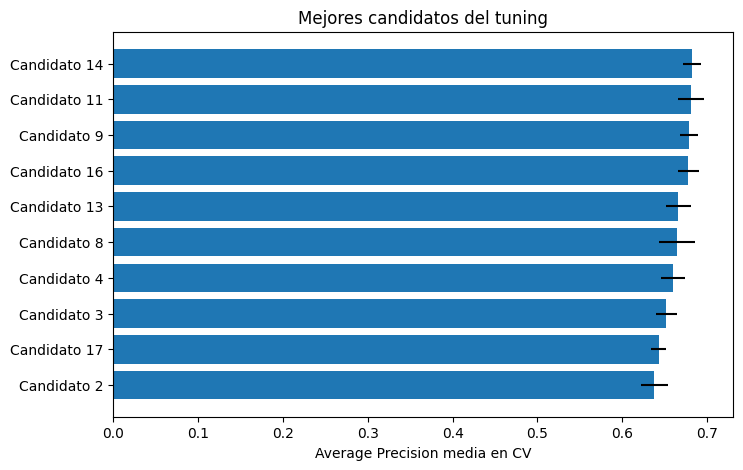

In [12]:
# Visualización de los mejores candidatos.
top = results.head(10).copy().iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(
    range(len(top)),
    top['mean_test_average_precision'],
    xerr=top['std_test_average_precision'],
)
plt.yticks(range(len(top)), [f'Candidato {i}' for i in top.index])
plt.xlabel('Average Precision media en CV')
plt.title('Mejores candidatos del tuning')
plt.show()

# 9. Selección del threshold usando VALIDATION

Hasta este punto seleccionamos **hiperparámetros**, pero la red aún produce probabilidades/scores.

Ahora usamos `X_val` para decidir el umbral que maximiza F1. Esta decisión **no se toma dentro de test**.

In [13]:
def positive_class_probability(estimator, X_data):
    """Devuelve P(Y=1) de forma robusta para un clasificador binario."""
    proba = np.asarray(estimator.predict_proba(X_data))

    if proba.ndim == 2 and proba.shape[1] >= 2:
        return proba[:, 1]
    return proba.ravel()


def metrics_at_threshold(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    return pd.Series({
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    })


y_val_prob = positive_class_probability(best_model, X_val)

print(f'Validation ROC-AUC: {roc_auc_score(y_val, y_val_prob):.4f}')
print(f'Validation AP     : {average_precision_score(y_val, y_val_prob):.4f}')

Validation ROC-AUC: 0.8534
Validation AP     : 0.6739


Mejor threshold en validation: 0.2733
F1 en ese punto             : 0.6199


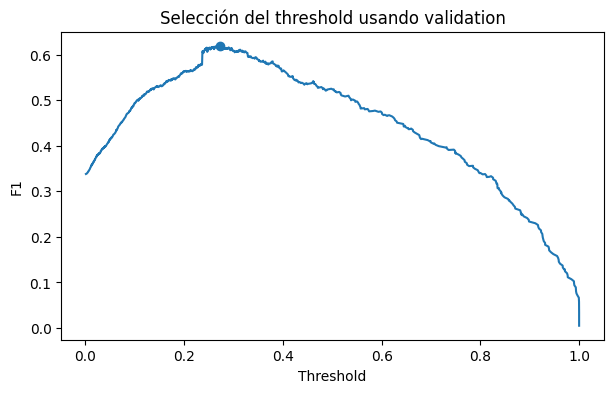

,threshold,accuracy,balanced_accuracy,precision,recall,f1
threshold = 0.50,0.500000,0.855,0.682149,0.791045,0.390663,0.523026
threshold optimizado en validation,0.273342,0.843,0.763335,0.610979,0.628993,0.619855


In [14]:
prec_v, rec_v, thresholds_v = precision_recall_curve(y_val, y_val_prob)

prec_for_t = prec_v[:-1]
rec_for_t = rec_v[:-1]
f1_for_t = 2 * prec_for_t * rec_for_t / (prec_for_t + rec_for_t + 1e-12)

best_idx = np.argmax(f1_for_t)
best_threshold = float(thresholds_v[best_idx])
best_val_f1 = float(f1_for_t[best_idx])

print(f'Mejor threshold en validation: {best_threshold:.4f}')
print(f'F1 en ese punto             : {best_val_f1:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(thresholds_v, f1_for_t)
plt.scatter([best_threshold], [best_val_f1], zorder=3)
plt.xlabel('Threshold')
plt.ylabel('F1')
plt.title('Selección del threshold usando validation')
plt.show()

comparison_val = pd.DataFrame([
    metrics_at_threshold(y_val, y_val_prob, 0.50),
    metrics_at_threshold(y_val, y_val_prob, best_threshold),
])
comparison_val.index = ['threshold = 0.50', 'threshold optimizado en validation']
display(comparison_val)

# 10. Evaluación final sobre TEST

Ahora sí usamos el conjunto de prueba.

A partir de aquí no deberíamos seguir modificando hiperparámetros ni threshold basándonos en estos resultados. Si lo hacemos repetidamente, `test` deja de representar datos realmente no vistos.

In [15]:
y_test_prob = positive_class_probability(best_model, X_test)
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print(f'Test ROC-AUC: {roc_auc_score(y_test, y_test_prob):.4f}')
print(f'Test AP     : {average_precision_score(y_test, y_test_prob):.4f}')
print()

print(classification_report(
    y_test,
    y_test_pred,
    target_names=['No churn', 'Churn'],
    digits=3,
    zero_division=0,
))

comparison_test = pd.DataFrame([
    metrics_at_threshold(y_test, y_test_prob, 0.50),
    metrics_at_threshold(y_test, y_test_prob, best_threshold),
])
comparison_test.index = ['threshold = 0.50', 'threshold elegido en validation']
display(comparison_test)

Test ROC-AUC: 0.8614
Test AP     : 0.7006

              precision    recall  f1-score   support

    No churn      0.906     0.889     0.897      1593
       Churn      0.595     0.639     0.616       407

    accuracy                          0.838      2000
   macro avg      0.750     0.764     0.757      2000
weighted avg      0.843     0.838     0.840      2000



,threshold,accuracy,balanced_accuracy,precision,recall,f1
threshold = 0.50,0.500000,0.868,0.707688,0.835681,0.437346,0.574194
threshold elegido en validation,0.273342,0.838,0.763855,0.594966,0.638821,0.616114


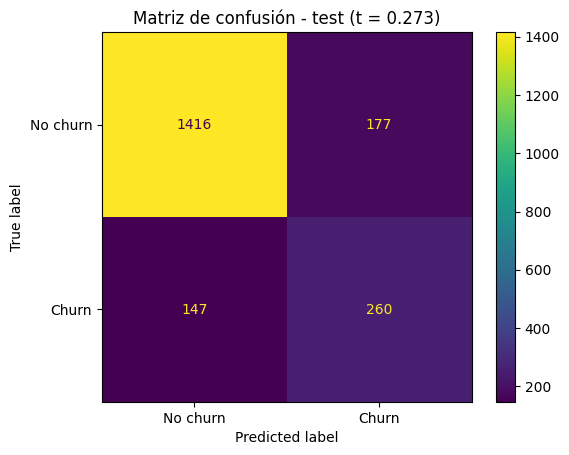

In [16]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No churn", "Churn"],
)
disp.plot(values_format="d")
plt.title(f"Matriz de confusión - test (t = {best_threshold:.3f})")
plt.show()


# 11. Ideas para discutir en clase

1. ¿Por qué el preprocesador debe estar dentro del `Pipeline`?
2. ¿Qué diferencia existe entre los folds internos de CV, `X_val` y `X_test`?
3. ¿Por qué escogimos `average_precision` como criterio de `refit`?
4. ¿Qué cambiaría si usáramos `refit='f1'`?
5. ¿Por qué `f1` sí depende de un threshold mientras ROC-AUC/AP trabajan con scores continuos?
6. ¿Qué significa que dos configuraciones tengan medias parecidas pero desviaciones estándar diferentes?
7. ¿Por qué `best_score_` no debe reportarse como “desempeño final del modelo”?
8. ¿Cuándo sería razonable incluir `batch_size`, `epochs` o `class_weight` dentro del espacio de búsqueda?

## Inspeccionar qué configuraciones fueron realmente sorteadas

Esta tabla es especialmente útil en `RandomizedSearchCV`, porque los candidatos no estaban escritos explícitamente uno por uno antes del entrenamiento.

In [17]:
random_draws = results[param_cols].copy()
display(random_draws.head(18))

,param_clf__batch_size,param_clf__dropout_rate,param_clf__learning_rate,param_clf__units1,param_clf__units2
14,32,0.480586,0.002722,64,12
11,64,0.331261,0.000339,96,48
9,32,0.115447,0.000257,48,24
16,32,0.070462,0.002306,16,8
13,64,0.197575,0.003753,96,24
8,32,0.482816,0.002363,16,12
4,64,0.262378,0.000542,16,16
3,64,0.000389,0.004850,16,24
17,128,0.211701,0.000469,32,16
2,128,0.010292,0.004445,48,48


## Resumen conceptual: RandomizedSearchCV

`RandomizedSearchCV` suele ser preferible cuando:

- hay muchos hiperparámetros;
- algunos son continuos (`learning_rate`, `dropout`, regularización, etc.);
- entrenar cada candidato es costoso;
- queremos controlar el presupuesto con `n_iter`.

Una idea importante es que **Random Search no significa una búsqueda de baja calidad**. En espacios de alta dimensión, puede usar el presupuesto de forma mucho más eficiente que una malla rígida, porque no obliga a probar todas las combinaciones posibles entre valores que quizá tengan poca influencia.

Una estrategia práctica común es:

```text
1. RandomizedSearchCV amplio
2. identificar una región prometedora
3. GridSearchCV pequeño alrededor de esa región
```

Así combinamos exploración amplia con refinamiento local.